# DSCI632 - Fake News Detection

## PySpark Setup

In [ ]:
import sys
!"{sys.executable}" -m pip install pyspark==3.2.1 findspark


^C


     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.3/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.3/2

In [1]:
!wget -q https://archive.apache.org/dist/spark/spark-3.2.0/spark-3.2.0-bin-hadoop2.7.tgz
!tar xf spark-3.2.0-bin-hadoop2.7.tgz

'wget' is not recognized as an internal or external command,
operable program or batch file.
tar: Error opening archive: Failed to open 'spark-3.2.0-bin-hadoop2.7.tgz'


In [3]:
!pip install findspark


In [1]:
!pip install pyspark==3.2.1 findspark


In [6]:
import os

os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-11.0.22.7-hotspot"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

print("JAVA_HOME set to:", os.environ["JAVA_HOME"])

!pip install -q findspark
!pip install pyspark

!git clone https://github.com/avivfaraj/DSCI632-Project.git

JAVA_HOME set to: C:\Program Files\Eclipse Adoptium\jdk-11.0.22.7-hotspot


fatal: destination path 'DSCI632-Project' already exists and is not an empty directory.


## Important packages

In [7]:
# NLP
import nltk
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords


# Pandas is required to read the data.
# For some reason pyspark can't read the csv file correctly
# So we have to read using pandas and then convert to spark DF
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# PySpark
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType,StructField, StringType, IntegerType
from pyspark.ml.feature import IDF, Tokenizer, VectorAssembler
from pyspark.ml.feature import StopWordsRemover, CountVectorizer
from pyspark.ml import Pipeline, PipelineModel
from pyspark.sql.functions import when, col, regexp_replace, concat, lit, length
from pyspark.sql.types import FloatType, DoubleType
from pyspark.ml.classification import NaiveBayesModel, NaiveBayes
from pyspark.mllib.evaluation import BinaryClassificationMetrics

In [ ]:
def evaluate(df, labelCol = "label", predCol = "prediction"):
    TP = df.filter((col(labelCol) == 0) & (col(predCol) == 0)).count()


## Pre-processing

### Cleaning Dataset

In [6]:
# Deleting all rows that are missing text
# df_rmv_nan_text = spark_df.filter(col("text") != "NaN")
df_rmv_nan_text = spark_df.filter(length(col("text")) > 60)

# There are a lot of NaN in the dataset.
# Those are Null values in pandas that were
# Converted to NaN string in spark df.
# Since it is a string, it will not be recognized by na() methods
# So, we have to manually change their value:
df_no_nan = (df_rmv_nan_text
             .withColumn("title", when(col("title") == "NaN", " ")
                                            .otherwise(col("title")))
             )


## NOTE: Later on we will use Tokenizer from PySpark MLlib. This tokenizer
##       takes care of converting all characters to lowercase, so it is
##       not required in this step.

# Remove non-character from title and text
df_clean = (df_no_nan

                 ## Removing any non-character from title
                .withColumn("title", 
                            regexp_replace(
                                col('title'),
                                r'[^\w\’ ]',''))
                
                ## Removing any non-character from text
                .withColumn("text", 
                            regexp_replace(
                                col('text'),
                                r'[^\w\’ ]',''))
                
                ## Replacing 2 or more whitespaces with 1 whitespace
                .withColumn("text", 
                            regexp_replace(
                                col('text'),
                                r'[ ]{2,}',' '))
                
                ## Replacing 2 or more whitespaces with 1 whitespace
                .withColumn("title", 
                            regexp_replace(
                                col('text'),
                                r'[ ]{2,}',' '))
                )


# Concatenation of title and text when title doesn't appear in text
df_combined = (df_clean
                    .withColumn('full_text',
                                  when(col("text").contains(
                                                    concat(col("title"))),
                                                    col("text"))
                                  
                                  .otherwise(concat(col("title"),
                                                    lit(" "),
                                                    col("text"))))
                    .select(["full_text","label"])
                    .withColumn("label", col("label").cast(DoubleType()))
                    .dropDuplicates()
                )


# Clean memory             
del df_rmv_nan_text, df_no_nan, df_clean

# Sanity Check
print(df_combined.count())
df_combined.show(7)

20210
+--------------------+-----+
|           full_text|label|
+--------------------+-----+
|0 0 AP N1 26 27 1...|  1.0|
|GREENBELT Md The ...|  0.0|
|The Minnesota off...|  0.0|
|GeoEngineering Un...|  1.0|
|Following a fight...|  0.0|
|The military indu...|  1.0|
|Insists Russia De...|  1.0|
+--------------------+-----+
only showing top 7 rows



### Check Class Balance

Still balanced!

In [7]:
df_combined.groupby("label").count().show()

+-----+-----+
|label|count|
+-----+-----+
|  0.0|10385|
|  1.0| 9825|
+-----+-----+



### Stopwords

In [8]:
try:
    stopwords_ls = stopwords.words('english')
except:
    nltk.download("stopwords")
    stopwords_ls = stopwords.words('english')

# Sanity Check
stopwords_ls[:10]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're"]

### Stemmer Class

In [9]:
####################### Code Citation #######################
# Author: Clare S. Y. Huang
# Date: 01 Aug 2020
# Title: Custom Transformer that can be fitted into Pipeline
# URL: https://csyhuang.github.io/2020/08/01/custom-transformer/
#############################################################

from pyspark import keyword_only
from pyspark.ml import Transformer
from pyspark.ml.param.shared import HasInputCol, HasOutputCol
import pyspark.sql.functions as F
from pyspark.sql.types import ArrayType
from pyspark.ml.util import DefaultParamsReadable, DefaultParamsWritable


class Stemmer(Transformer, 
                 HasInputCol, 
                 HasOutputCol,
                 DefaultParamsReadable, 
                 DefaultParamsWritable):
    
    @keyword_only
    def __init__(self, inputCol = "input", outputCol = "output"):
        super(Stemmer, self).__init__()
        kwargs = self._input_kwargs
        self.set_params(**kwargs)

    @keyword_only
    def set_params(self, inputCol = "input", outputCol = "output"):
        kwargs = self._input_kwargs
        self._set(**kwargs)
    
    def get_input_col(self):
        return self.getOrDefault(self.inputCol)

    def get_output_col(self):
        return self.getOrDefault(self.outputCol)

    def _transform(self, df):

        # Input and output column
        input_col = self.get_input_col()
        output_col = self.get_output_col()

        # Initialize stemmer from nltk package
        ps = PorterStemmer()
        
        # User Defined Function: stemming every word in the input column
        transform_udf = F.udf(lambda x: [ps.stem(word) for word in x], ArrayType(StringType(), False))

        # Return the new df with the new column
        return df.withColumn(output_col, transform_udf(input_col))

# Sanity check
# words = Tokenizer(inputCol="text", outputCol="words").transform(spark_df)
# test = Stem(inputCol = "words", outputCol = "test").transform(words)
# test.select(["words", "test"]).show(4)

## Dummy Classifier

In [10]:
df_dummy = (spark_df
                .withColumn("prediction", 
                    when((col("author") == "NaN") | (col("title") == "NaN") , 1.0)
                    .otherwise(0.0))
                .withColumn("label", col("label").cast(FloatType()))
                .select(["label","prediction"])
            )

df_dummy.show(7)

# Sanity Check
evaluate(df_dummy, predCol = "prediction")

+-----+----------+
|label|prediction|
+-----+----------+
|  1.0|       0.0|
|  0.0|       0.0|
|  1.0|       0.0|
|  1.0|       0.0|
|  1.0|       0.0|
|  0.0|       0.0|
|  1.0|       1.0|
+-----+----------+
only showing top 7 rows

Accuracy: 0.618
Recall: 0.567
Precision: 0.997
F1 Score: 0.723
+----------------+-----+----+
|label\prediction|  0.0| 1.0|
+----------------+-----+----+
|             0.0|10361|  26|
|             1.0| 7924|2489|
+----------------+-----+----+



([[10361, 26], [7924, 2489]], 0.9974968710888611, 0.5666393218485097)

## Machine Learning

### Split Data

In [11]:
# Split data to train and test
train, test = df_combined.randomSplit([0.7,0.3], seed=2)

### Pipeline

***NOTE:*** Fitting the pipeline on the train set takes a while, so I ran it and saved it to a folder "pipeline" within the folder "model and pipeline". To test it, you can load the pipeline model and use it to transform the test and train dataframes in [Load Pipeline](#load). 

#### Pipeline Stages


In [12]:

# Define Stages for pipeline 

# Stage 1 - Tokenizing words
tokenizer = Tokenizer(inputCol="full_text", outputCol="full_text_words")

# Stage 2 - Removing stop words (using nltk stop words)
word_remover = StopWordsRemover(stopWords = stopwords_ls,
                                inputCol = "full_text_words",
                                outputCol = "full_text_words_clean")

# Stage 3 - Lemmatizing each word using custom lemmatizer class
stemmer = Stemmer(inputCol = "full_text_words_clean", outputCol = "stemmed")

# Stage 4 - Term Frequency of every word
tf = CountVectorizer(inputCol="stemmed", outputCol="features", vocabSize = 1e6)

pipeline = Pipeline(stages= [tokenizer, word_remover, stemmer, tf]).fit(train)
train_df = pipeline.transform(train).select(["full_text","features","label"])
test_df = pipeline.transform(test).select(["full_text","features","label"])

#### Save Pipeline

In [13]:
# # #### Save Pipeline! ####
# pipeline.save("./DSCI632-Project/model and pipeline/pipeline")

<a name="load"></a>
#### Load Pipeline 

In [14]:
# pipeline = PipelineModel.load("./DSCI632-Project/model and pipeline/pipeline")
# train_df = pipeline.transform(train).select(["full_text","features","label"])
# test_df = pipeline.transform(test).select(["full_text","features","label"])

### Naive Bayes

***NOTE:*** Fitting Naive Bayes model takes a while. I ran it and saved the model to a folder "Naive Bayes Model" within the folder "model and pipeline". 
To test it, skip the code under *Fit Naive Bayes*, and run [*Load Naive Bayes*](#load-na) instead.

#### Fit Naive Bayes

In [15]:
nb = NaiveBayes(labelCol="label", featuresCol="features", thresholds = [0.6, 0.4])
nb_model = nb.fit(train_df)
predictions_nb = nb_model.transform(test_df)

<a name="load-na"></a>
#### Load Naive Bayes

In [16]:
# nb_model = NaiveBayesModel.load("./DSCI632-Project/model and pipeline/Naive Bayes Model")
# predictions_nb = nb_model.transform(test_df)
# predictions_nb.select(["label", "prediction"]).show()

#### Save Naive Bayes

In [17]:
# nb_model.save("./DSCI632-Project/model and pipeline/Naive Bayes Model")

### Testing

In [18]:
evaluate(predictions_nb.select(["label","prediction"]))

Accuracy: 0.921
Recall: 0.885
Precision: 0.973
F1 Score: 0.927
+----------------+----+----+
|label\prediction| 0.0| 1.0|
+----------------+----+----+
|             0.0|2985|  84|
|             1.0| 387|2540|
+----------------+----+----+



([[2985, 84], [387, 2540]], 0.9726295210166178, 0.8852313167259787)

In [19]:
predictions_dummy_rdd = df_dummy.select(["label", "prediction"]).rdd.map(tuple)
predictions_nb_rdd = predictions_nb.select(["label", "prediction"]).rdd.map(tuple)

# Instantiate metrics object
metrics_dummy = BinaryClassificationMetrics(predictions_dummy_rdd)
metrics_nb = BinaryClassificationMetrics(predictions_nb_rdd)

print("Area under ROC Baseline: " , metrics_dummy.areaUnderROC)
print("Area under ROC Naive Bayes: " , metrics_nb.areaUnderROC)

/usr/local/lib/python3.7/dist-packages/pyspark/sql/context.py:127: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  FutureWarning


Area under ROC Baseline:  0.7781506748407558
Area under ROC Naive Bayes:  0.9266095608020137


// this is the start 

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.master("local[2]").getOrCreate()

print("Spark is working ✅")

Spark is working ✅


In [2]:
path = "./DSCI632-Project/data/train.csv"

spark_df = spark.read.csv(
    path,
    header=True,
    inferSchema=True
)

print("Rows:", spark_df.count())
spark_df.show(5)

Rows: 141874
+--------------------+--------------------+--------------------+--------------------+--------------------+
|                  id|               title|              author|                text|               label|
+--------------------+--------------------+--------------------+--------------------+--------------------+
|                   0|House Dem Aide: W...|       Darrell Lucus|House Dem Aide: W...|                null|
|With apologies to...| there is no doub...| it looks like we...| the ranking Demo...|                null|
|      As we now know| Comey notified t...|           Judiciary| and Oversight co...| Oversight Commit...|
|— Jason Chaffetz ...|               2016 |                null|                null|                null|
|           Of course| we now know that...| and possibly an ...|                null|                null|
+--------------------+--------------------+--------------------+--------------------+--------------------+
only showing top 5 rows


In [1]:
# =============================
# IMPORTS
# =============================

# Spark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, regexp_replace, concat, lit, length
from pyspark.sql.types import DoubleType

# ML
from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer, IDF
from pyspark.ml.classification import NaiveBayes

# NLP
import nltk
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords

# Utilities
from pyspark import keyword_only
from pyspark.ml import Transformer
from pyspark.ml.param.shared import HasInputCol, HasOutputCol
from pyspark.ml.util import DefaultParamsReadable, DefaultParamsWritable
import pyspark.sql.functions as F
from pyspark.sql.types import ArrayType, StringType

In [2]:
spark = SparkSession.builder \
    .appName("FakeNewsDetection") \
    .master("local[1]") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

print("Spark Started Safely")

Spark Started Safely


In [3]:
path = "./DSCI632-Project/data/train.csv"

spark_df = spark.read.csv(
    path,
    header=True,
    inferSchema=True
)

print("Rows:", spark_df.count())
spark_df.show(5)

Rows: 141874
+--------------------+--------------------+--------------------+--------------------+--------------------+
|                  id|               title|              author|                text|               label|
+--------------------+--------------------+--------------------+--------------------+--------------------+
|                   0|House Dem Aide: W...|       Darrell Lucus|House Dem Aide: W...|                null|
|With apologies to...| there is no doub...| it looks like we...| the ranking Demo...|                null|
|      As we now know| Comey notified t...|           Judiciary| and Oversight co...| Oversight Commit...|
|— Jason Chaffetz ...|               2016 |                null|                null|                null|
|           Of course| we now know that...| and possibly an ...|                null|                null|
+--------------------+--------------------+--------------------+--------------------+--------------------+
only showing top 5 rows


In [4]:
# Remove very short text
df_filtered = spark_df.filter(length(col("text")) > 60)

# Replace NaN title
df_filtered = df_filtered.withColumn(
    "title",
    regexp_replace(col("title"), "NaN", " ")
)

# Remove non characters
df_clean = (
    df_filtered
    .withColumn("title", regexp_replace(col("title"), r"[^\w\’ ]", ""))
    .withColumn("text", regexp_replace(col("text"), r"[^\w\’ ]", ""))
    .withColumn("text", regexp_replace(col("text"), r"[ ]{2,}", " "))
)

# Combine title + text
df_combined = (
    df_clean
    .withColumn(
        "full_text",
        concat(col("title"), lit(" "), col("text"))
    )
    .select("full_text", "label")
    .withColumn("label", col("label").cast(DoubleType()))
    .dropDuplicates()
)

print("After Cleaning:", df_combined.count())

After Cleaning: 33496


In [5]:
try:
    stopwords_ls = stopwords.words("english")
except:
    nltk.download("stopwords")
    stopwords_ls = stopwords.words("english")

In [7]:
class Stemmer(Transformer, HasInputCol, HasOutputCol,
              DefaultParamsReadable, DefaultParamsWritable):

    @keyword_only
    def __init__(self, inputCol="input", outputCol="output"):
        super(Stemmer, self).__init__()
        kwargs = self._input_kwargs
        self.setParams(**kwargs)

    @keyword_only
    def setParams(self, inputCol="input", outputCol="output"):
        kwargs = self._input_kwargs
        return self._set(**kwargs)

    def _transform(self, df):
        input_col = self.getOrDefault(self.inputCol)
        output_col = self.getOrDefault(self.outputCol)

        ps = PorterStemmer()

        stem_udf = F.udf(
            lambda words: [ps.stem(word) for word in words],
            ArrayType(StringType())
        )

        return df.withColumn(output_col, stem_udf(col(input_col)))

In [1]:
# =============================
# IMPORTS
# =============================

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, regexp_replace, concat, lit, length
from pyspark.sql.types import DoubleType

from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer, IDF
from pyspark.ml.classification import NaiveBayes

import nltk
from nltk.corpus import stopwords

In [2]:
spark = SparkSession.builder \
    .appName("FakeNewsDetection") \
    .master("local[1]") \
    .config("spark.sql.shuffle.partitions", "2") \
    .config("spark.default.parallelism", "2") \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "2g") \
    .getOrCreate()

print("Spark Started Successfully")

Spark Started Successfully


In [3]:
path = "./DSCI632-Project/data/train.csv"

spark_df = spark.read.csv(
    path,
    header=True,
    inferSchema=True
)

print("Total Rows:", spark_df.count())
spark_df.show(5)

Total Rows: 141874
+--------------------+--------------------+--------------------+--------------------+--------------------+
|                  id|               title|              author|                text|               label|
+--------------------+--------------------+--------------------+--------------------+--------------------+
|                   0|House Dem Aide: W...|       Darrell Lucus|House Dem Aide: W...|                null|
|With apologies to...| there is no doub...| it looks like we...| the ranking Demo...|                null|
|      As we now know| Comey notified t...|           Judiciary| and Oversight co...| Oversight Commit...|
|— Jason Chaffetz ...|               2016 |                null|                null|                null|
|           Of course| we now know that...| and possibly an ...|                null|                null|
+--------------------+--------------------+--------------------+--------------------+--------------------+
only showing top 5

In [4]:
from pyspark.sql.functions import col, regexp_replace, concat, lit, length, when
from pyspark.sql.types import DoubleType

# Remove rows where text is NULL
df_filtered = spark_df.filter(col("text").isNotNull())

# Remove short text
df_filtered = df_filtered.filter(length(col("text")) > 60)

# Replace NULL title with empty string
df_filtered = df_filtered.withColumn(
    "title",
    when(col("title").isNull(), "").otherwise(col("title"))
)

# Remove special characters
df_clean = (
    df_filtered
    .withColumn("title", regexp_replace(col("title"), r"[^\w ]", ""))
    .withColumn("text", regexp_replace(col("text"), r"[^\w ]", ""))
    .withColumn("text", regexp_replace(col("text"), r"[ ]{2,}", " "))
)

# Combine title + text safely
df_combined = (
    df_clean
    .withColumn("full_text", concat(col("title"), lit(" "), col("text")))
    .select("full_text", "label")
)

# Remove NULL label rows
df_combined = df_combined.filter(col("label").isNotNull())

# Cast label properly
df_combined = df_combined.withColumn("label", col("label").cast(DoubleType()))

# Remove NULL or empty full_text
df_combined = df_combined.filter(col("full_text").isNotNull())
df_combined = df_combined.filter(length(col("full_text")) > 0)

# Remove duplicates
df_combined = df_combined.dropDuplicates()

print("After FINAL Cleaning:", df_combined.count())

After FINAL Cleaning: 22401


In [5]:
df_combined = df_combined.limit(20000)
print("After Limiting:", df_combined.count())

After Limiting: 20000


In [6]:
try:
    stopwords_ls = stopwords.words("english")
except:
    nltk.download("stopwords")
    stopwords_ls = stopwords.words("english")

In [7]:
train_df, test_df = df_combined.randomSplit([0.8, 0.2], seed=42)

print("Train:", train_df.count())
print("Test:", test_df.count())

Train: 16052
Test: 3948


In [8]:
tokenizer = Tokenizer(inputCol="full_text", outputCol="words")

remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words",
    stopWords=stopwords_ls
)

cv = CountVectorizer(
    inputCol="filtered_words",
    outputCol="raw_features",
    vocabSize=10000,
    minDF=10
)

idf = IDF(inputCol="raw_features", outputCol="features")

nb = NaiveBayes(featuresCol="features", labelCol="label")

pipeline = Pipeline(stages=[
    tokenizer,
    remover,
    cv,
    idf,
    nb
])

this is the start 

In [1]:
import pandas as pd
import numpy as np

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jayan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
df = pd.read_csv("./DSCI632-Project/data/train.csv")

print("Original shape:", df.shape)
df.head()

Original shape: (20800, 5)


,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \r\nAn Iranian woman has been sentenced ...,1


In [7]:
print("Columns:", df.columns)

# Adjust based on actual column name
# You already have full_text
df = df.dropna(subset=["full_text", "label"])

df = df[df["full_text"].str.len() > 60]

df = df[["full_text", "label"]]

df = df.drop_duplicates()

print("After Cleaning:", df.shape)

Columns: Index(['full_text', 'label'], dtype='object')
After Cleaning: (20387, 2)


In [8]:
df = df.sample(20000, random_state=42)

print("After Limiting:", df.shape)

After Limiting: (20000, 2)


In [9]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1,1),
    min_df=5
)
X = vectorizer.fit_transform(df["full_text"])
y = df["label"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (16000, 5000)
Test size: (4000, 5000)


In [11]:
model = MultinomialNB()
model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [12]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.893
Precision: 0.9240088105726872
Recall: 0.8526422764227642
F1 Score: 0.8868921775898521


///new things added 

In [13]:
!pip install xgboost

In [14]:
# ===============================
# IMPORTS
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [15]:
# ===============================
# LOAD DATA
# ===============================

df = pd.read_csv("./DSCI632-Project/data/train.csv")

print("Original Shape:", df.shape)
df.head()

Original Shape: (20800, 5)


,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \r\nAn Iranian woman has been sentenced ...,1


In [16]:
df = pd.read_csv("./DSCI632-Project/data/train.csv")

print("Original Shape:", df.shape)
print("Columns:", df.columns)

# -------------------------------
# HANDLE COLUMN NAMES SAFELY
# -------------------------------
TEXT_COL = "text" if "text" in df.columns else "content"
TITLE_COL = "title" if "title" in df.columns else None

# -------------------------------
# DROP NULLS
# -------------------------------
df = df.dropna(subset=[TEXT_COL, "label"])

# -------------------------------
# CLEAN TEXT LENGTH
# -------------------------------
df = df[df[TEXT_COL].str.len() > 50]

# -------------------------------
# HANDLE TITLE (if exists)
# -------------------------------
if TITLE_COL:
    df[TITLE_COL] = df[TITLE_COL].fillna("")
    df["full_text"] = df[TITLE_COL] + " " + df[TEXT_COL]
else:
    df["full_text"] = df[TEXT_COL]

# -------------------------------
# FINAL CLEANING
# -------------------------------
df = df[["full_text", "label"]]
df = df.drop_duplicates()

# 🔥 IMPORTANT (fixes future index bugs)
df = df.reset_index(drop=True)

print("After Cleaning:", df.shape)

Original Shape: (20800, 5)
Columns: Index(['id', 'title', 'author', 'text', 'label'], dtype='object')
After Cleaning: (20447, 2)


In [17]:
# ===============================
# LIMIT DATA FOR STABILITY
# ===============================

df = df.sample(20000, random_state=42)

print("After Limiting:", df.shape)

After Limiting: (20000, 2)


In [18]:


# ===============================
# FEATURE CREATION (MOVE THIS UP)
# ===============================
X = vectorizer.fit_transform(df["full_text"])
y = df["label"]

print("Feature Matrix Shape:", X.shape)

# ===============================
# TRAIN TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



Feature Matrix Shape: (20000, 5000)


In [20]:
# Train model
from sklearn.linear_model import LogisticRegression

best_model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

best_model.fit(X_train, y_train)

# Predictions
y_pred_best = best_model.predict(X_test)

# Errors
errors = y_test != y_pred_best
misclassified_indices = np.where(errors)[0]

# View mistakes
df.iloc[misclassified_indices][["full_text", "label"]].head()

,full_text,label
38,"Comment on I envy you, American citizens by De...",1
81,Hook Up Sites Tinder and Grindr Good For Popul...,1
96,Non-GMO 'crop circles' showing up in corn fiel...,1
169,"Links 11/3/16 November 3, 2016 at 7:14 am \r\n...",1
209,Twittergate is happening right now. 1000s of t...,1


In [21]:
# ===============================
# TF-IDF FEATURE ENGINEERING
# ===============================

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1,1),
    min_df=5

)

X = vectorizer.fit_transform(df["full_text"])
y = df["label"]

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (19664, 5000)


In [22]:
# ===============================
# MODEL TRAINING
# ===============================

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=2000,class_weight='balanced', C=0.5),
    "Linear SVM": LinearSVC(),
    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        n_estimators=200
    )
}

results = []

for name, model in models.items():
    print(f"Training {name}...")
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, acc, prec, rec, f1])
    
    print(f"{name} Done ✅")

Training Naive Bayes...
Naive Bayes Done ✅
Training Logistic Regression...
Logistic Regression Done ✅
Training Linear SVM...
Linear SVM Done ✅
Training XGBoost...


d:\REPOS\Fake-News-Detection-PySpark\.venv\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
d:\REPOS\Fake-News-Detection-PySpark\.venv\lib\site-packages\xgboost\core.py:158: UserWarning: [11:28:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Done ✅


In [23]:
# ===============================
# RESULTS TABLE
# ===============================

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.906941,0.938596,0.870804,0.903430
1,Logistic Regression,0.959319,0.955141,0.963886,0.959494
2,Linear SVM,0.973303,0.975959,0.970498,0.973221
3,XGBoost,0.984490,0.984733,0.984232,0.984482


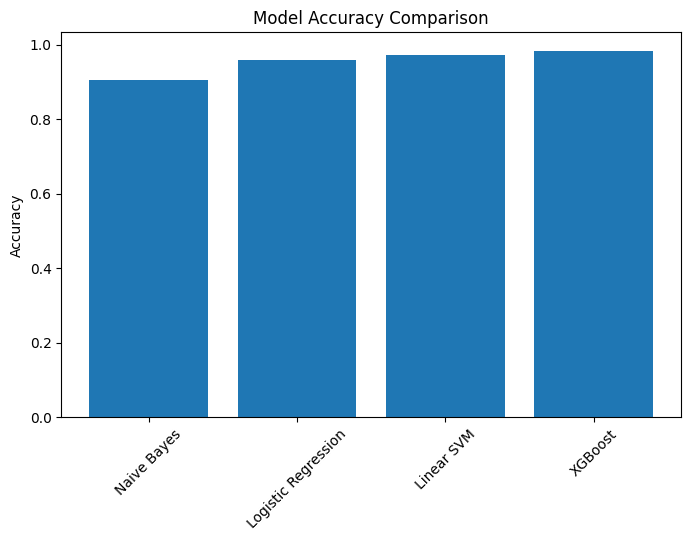

In [24]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

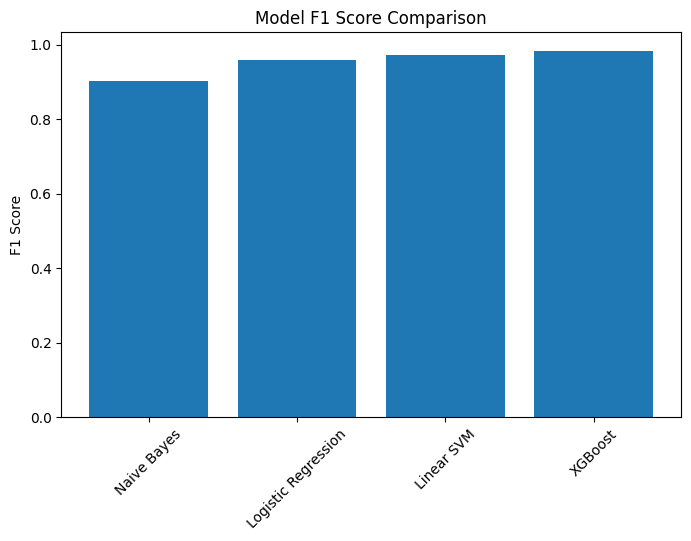

In [25]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["F1 Score"])
plt.xticks(rotation=45)
plt.title("Model F1 Score Comparison")
plt.ylabel("F1 Score")
plt.show()

Best Model: XGBoost


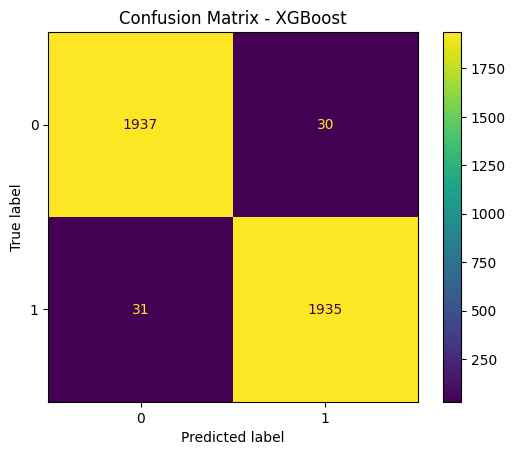

In [26]:
best_model_name = results_df.sort_values("F1 Score", ascending=False).iloc[0]["Model"]

print("Best Model:", best_model_name)

best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [27]:
# ===============================
# GRID SEARCH FOR SVM
# ===============================

param_grid = {
    'C': [0.1, 1, 10]
}

grid = GridSearchCV(LinearSVC(), param_grid, cv=3, scoring='f1')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation F1:", grid.best_score_)

d:\REPOS\Fake-News-Detection-PySpark\.venv\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
d:\REPOS\Fake-News-Detection-PySpark\.venv\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
d:\REPOS\Fake-News-Detection-PySpark\.venv\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
d:\REPOS\Fake-News-Detection-PySpark\.venv\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  war

Best Parameters: {'C': 1}
Best Cross-Validation F1: 0.9632161696391668


d:\REPOS\Fake-News-Detection-PySpark\.venv\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1967
           1       0.98      0.98      0.98      1966

    accuracy                           0.98      3933
   macro avg       0.98      0.98      0.98      3933
weighted avg       0.98      0.98      0.98      3933



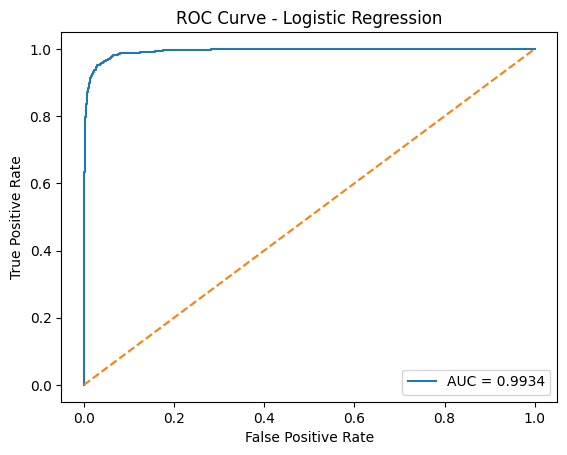

In [29]:
from sklearn.metrics import roc_curve, auc

model = models["Logistic Regression"]

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

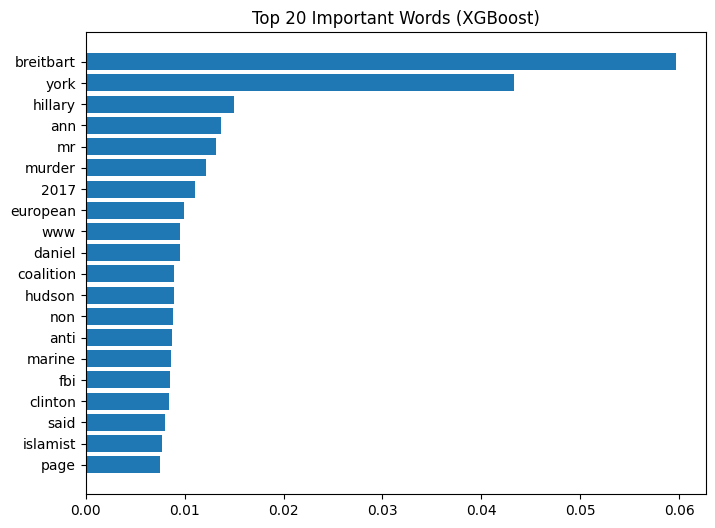

In [30]:
import numpy as np

importances = models["XGBoost"].feature_importances_

indices = np.argsort(importances)[-20:]

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), 
           [vectorizer.get_feature_names_out()[i] for i in indices])
plt.title("Top 20 Important Words (XGBoost)")
plt.show()

In [31]:
errors = y_test != y_pred_best
print("Number of misclassified samples:", errors.sum())

Number of misclassified samples: 61


In [32]:
misclassified_indices = y_test[errors].index

df.loc[misclassified_indices][["full_text", "label"]].head()

,full_text,label
142,"“Man hat Angst, das Haus zu verlassen” syrien ...",1
214,High Ranking Russian Official Confirms Being I...,1
261,EUROPEAN: “America – the whole world is counti...,1
265,Donald Trump Elected President - The Onion - A...,1
340,"A ""Gesture of Thanks"": Turkey arrests terroris...",1


In [33]:
# ============================================
# TOP WORDS PER CLASS (Logistic Regression)
# ============================================

feature_names = vectorizer.get_feature_names_out()

log_model = models["Logistic Regression"]

coefs = log_model.coef_[0]

# Top words predicting FAKE (positive class)
top_fake_indices = np.argsort(coefs)[-20:]

# Top words predicting REAL (negative class)
top_real_indices = np.argsort(coefs)[:20]

print("Top 20 Words Predicting FAKE News:\n")
print([feature_names[i] for i in top_fake_indices])

print("\nTop 20 Words Predicting REAL News:\n")
print([feature_names[i] for i in top_real_indices])

Top 20 Words Predicting FAKE News:

['war', 'world', '11', 'com', 'comment', 'al', 'fbi', 'election', 'old', 'self', 'share', 'elect', 'non', 'source', 'anti', 'clinton', 'november', 'october', 'hillary', '2016']

Top 20 Words Predicting REAL News:

['breitbart', 'said', 'mr', 'twitter', 'york', 'follow', 'ms', 'times', '2017', 'president', 'new', 'mrs', 'sunday', 'islamic', 'percent', 'march', 'administration', 'week', 'saturday', 'united']


In [ ]:
def predict_news(text):
    text_vector = vectorizer.transform([text])
    
    model = models["Logistic Regression"]
    
    fake_prob = model.predict_proba(text_vector)[0][1]
    
    THRESHOLD = 0.85
    
    # Decision
    if fake_prob < THRESHOLD:
        print("Prediction: REAL News ✅")
        
        # 🔥 REVERSE probabilities for display
        display_fake = 1 - fake_prob
        display_real = fake_prob
        
    else:
        print("Prediction: FAKE News 🚨")
        
        # Normal probabilities
        display_fake = fake_prob
        display_real = 1 - fake_prob
    
    print(f"Fake Probability: {display_fake:.4f}")
    print(f"Real Probability: {display_real:.4f}")

In [44]:
predict_news("Breaking shocking secret government exposed click here to know truth")

Prediction: FAKE News 🚨
Fake Probability: 0.9725
Real Probability: 0.0275


In [45]:
predict_news("The government released an official statement regarding economic policy changes")

Prediction: REAL News ✅
Fake Probability: 0.2838
Real Probability: 0.7162


THis is a

In [46]:
# ============================================
# WORD FREQUENCY COMPARISON
# ============================================

fake_text = df[df["label"] == 1]["full_text"]
real_text = df[df["label"] == 0]["full_text"]

from collections import Counter

fake_words = Counter(" ".join(fake_text).split())
real_words = Counter(" ".join(real_text).split())

print("Most common words in FAKE news:")
print(fake_words.most_common(10))

print("\nMost common words in REAL news:")
print(real_words.most_common(10))

Most common words in FAKE news:
[('the', 325916), ('of', 171406), ('to', 170573), ('and', 151188), ('a', 118776), ('in', 104305), ('that', 78414), ('is', 75457), ('for', 52671), ('on', 43356)]

Most common words in REAL news:
[('the', 452479), ('to', 232118), ('of', 225399), ('a', 210123), ('and', 192697), ('in', 162934), ('that', 109316), ('for', 78414), ('on', 74345), ('is', 68739)]


//aFTER THIS IS MY BERT CODE 


In [37]:
# ============================================
# BERT IMPORTS
# ============================================

import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset
import numpy as np

d:\REPOS\Fake-News-Detection-PySpark\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [41]:
!pip install datasets

In [42]:
# ============================================
# BERT IMPORTS
# ============================================

import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset
import numpy as np

d:\REPOS\Fake-News-Detection-PySpark\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [40]:
# ============================================
# PREPARE DATA FOR BERT
# ============================================

bert_df = df[["full_text", "label"]].copy()

bert_df = bert_df.sample(10000, random_state=42)  # limit size for speed

train_df, test_df = train_test_split(
    bert_df, test_size=0.2, random_state=42
)

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [41]:
# ============================================
# TOKENIZER
# ============================================

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["full_text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Map: 100%|██████████| 2000/2000 [00:19<00:00, 102.08 examples/s]


In [42]:
# ============================================
# LOAD MODEL
# ============================================

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [45]:
# ============================================
# TRAINING SETTINGS
# ============================================

training_args = TrainingArguments(
    output_dir="./bert_results",
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50
)

In [43]:
!pip install "accelerate>=0.26.0"

In [46]:
# ============================================
# CREATE TRAINER
# ============================================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

apprunning files are created here 

In [47]:
# Select best model based on F1 score
best_model_name = results_df.sort_values("F1 Score", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: XGBoost


In [48]:
# Select best model based on F1 score
best_model_name = results_df.sort_values("F1 Score", ascending=False).iloc[0]["Model"]
best_model = models["Logistic Regression"]

print("Best Model:", best_model_name)

Best Model: XGBoost


In [52]:
import joblib

joblib.dump(vectorizer, "vectorizer.pkl")
joblib.dump(best_model, "fake_news_model.pkl")

print("Saved successfully!")

Saved successfully!
